In [23]:
!pip install sentence-transformers seaborn

In [24]:
sentences = [
    # Cricket (4 sentences)
    "The batsman scored a century in the final match.",
    "The bowler delivered a fast yorker to dismiss the player.",
    "The cricket team celebrated after winning the world cup.",
    "The captain set an aggressive field placement during the match.",

    # Cooking (3 sentences)
    "The chef prepared a delicious pasta with fresh ingredients.",
    "Baking a chocolate cake requires precise measurements.",
    "The recipe calls for garlic, onions, and olive oil.",

    # Cybersecurity (3 sentences)
    "Hackers attempted to breach the company's firewall.",
    "Strong passwords help protect accounts from cyber attacks.",
    "Encryption ensures that sensitive data remains secure."
]

In [25]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

print("Embeddings shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (10, 384)


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)
print(similarity_matrix)

[[ 1.0000002   0.3750924   0.5373663   0.36649406 -0.02327408  0.13028622
  -0.07267622  0.03455016  0.01324105  0.02278115]
 [ 0.3750924   1.          0.2874952   0.312157    0.07784998  0.05552681
  -0.02791106  0.10178712 -0.00649736 -0.01537923]
 [ 0.5373663   0.2874952   1.0000001   0.28610647 -0.00296886  0.01370239
   0.00604835  0.00677361  0.00699141 -0.01410294]
 [ 0.36649406  0.312157    0.28610647  0.99999994  0.00460299 -0.04497651
  -0.05183859  0.09921235  0.05950402  0.03801019]
 [-0.02327408  0.07784998 -0.00296886  0.00460299  0.9999999   0.16207075
   0.44601876  0.08429856 -0.02784146  0.00585247]
 [ 0.13028622  0.05552681  0.01370239 -0.04497651  0.16207075  1.0000001
   0.07064891  0.01006783 -0.02104655  0.08157763]
 [-0.07267622 -0.02791106  0.00604835 -0.05183859  0.44601876  0.07064891
   1.          0.02892219  0.00539745 -0.02761986]
 [ 0.03455016  0.10178712  0.00677361  0.09921235  0.08429856  0.01006783
   0.02892219  1.          0.3418159   0.15108234]
 

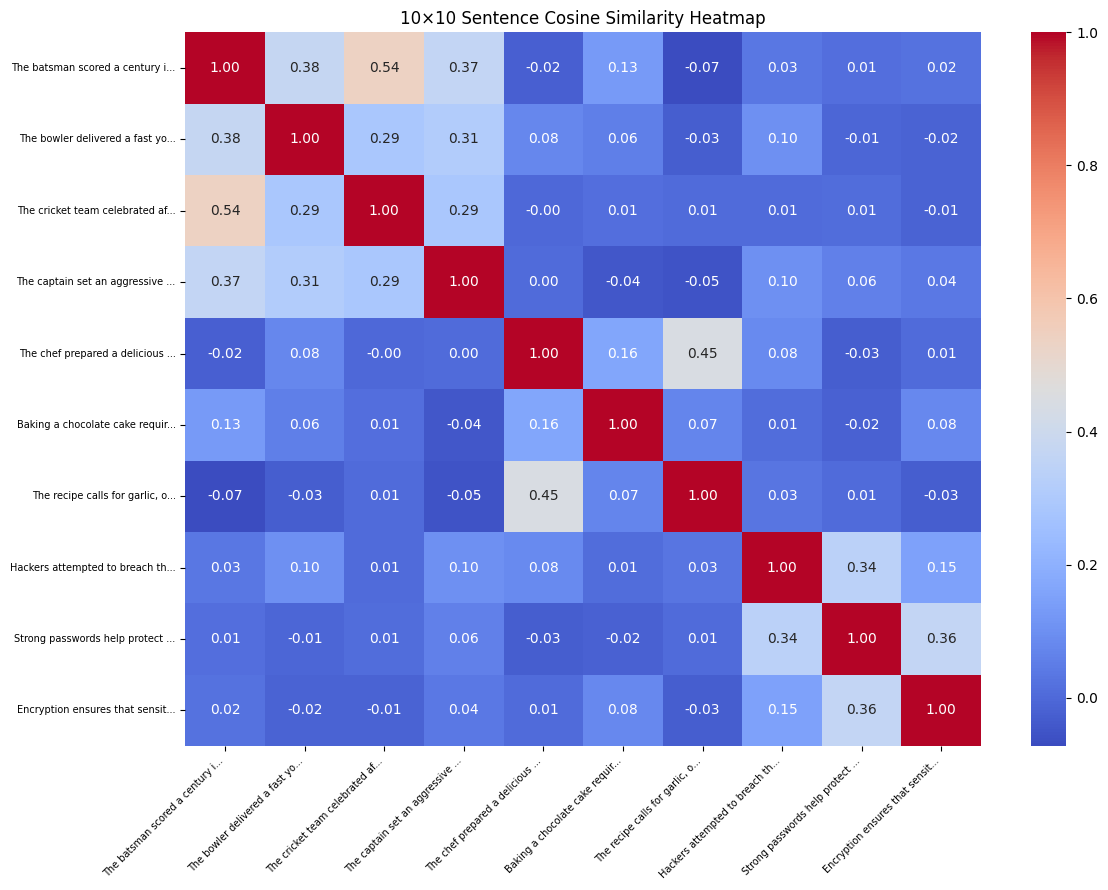

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

short_labels = [s[:30] + "..." for s in sentences]

plt.figure(figsize=(12, 9))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            xticklabels=short_labels, yticklabels=short_labels)
plt.title("10×10 Sentence Cosine Similarity Heatmap")
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [28]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

In [29]:
import numpy as np

query_similarities = cosine_similarity(query_embedding, embeddings)[0]
top_indices = np.argsort(query_similarities)[::-1][:2]

print(f"Query: '{query}'\n")
print("Top 2 most similar sentences:\n")
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank}. \"{sentences[idx]}\"")
    print(f"     Similarity Score: {query_similarities[idx]:.4f}\n")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:

  1. "The batsman scored a century in the final match."
     Similarity Score: 0.5679

  2. "The bowler delivered a fast yorker to dismiss the player."
     Similarity Score: 0.5103

